In [210]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt

In [211]:
data_file_path = Path("../data") / "bcidatasetIV2a" / "A09T.npz"
data = np.load(data_file_path)

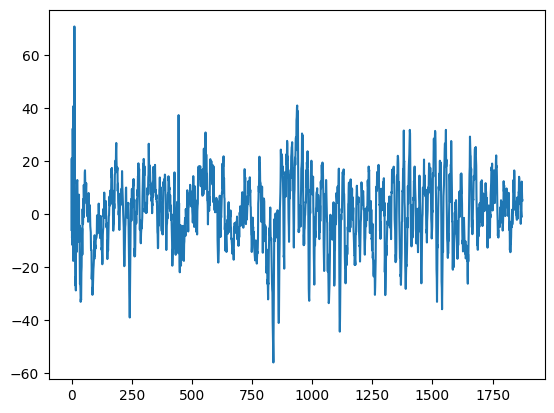

In [212]:
fs = 250  # Sampling frequency
signal = data['s']
# The index 7 represent the channel C3, for the info of each channel read the original paper.
channelC3 = signal[:, 7]

x = 7  # this is the event number that I want to extract

# Extract the type of the event 7 in this case the type is 768 (in the table this is a Start of a trial event).
etype = data['etyp'].T[0, x]
# This is the position of the event in the raw signal
epos = data['epos'].T[0, x]
edur = data['edur'].T[0, x]  # And this is the duration of this event

# Then I extract the signal related the event selected.
trial = channelC3[epos:epos+edur]

# The selected event type is 768 (Start of a trial) if you see the array of event types ('etype')
# you can observe the next event is 772 (Cue onset tongue) with that you can deduce de class of
# this trial: Tongue Imagery Task.

# Then for know the class of this trial (7) you need to read the type of the inmediate next event
trial_type = data['etyp'].T[0, x+1]

# For know the order of this events, you can see the data['etyp'] array.

# You can plot this event with matplotlib
plt.plot(trial)
plt.show()

In [213]:
events_raw = data['etyp'].T[0]
events_raw.shape

(639,)

In [214]:
data['edur'].shape

(639, 1)

In [215]:
result = np.zeros((0, 22, fs*6), dtype=np.float64)
events = []

for i in range(len(events_raw)):
    etype = events_raw[i]
    epos = data['epos'].T[0, i]
    edur = data['edur'].T[0, i]
    
    if not etype in {769, 770, 771, 772}:
        continue

    trial = signal.T[:22, epos-fs*1:epos+fs*(3+2)]
    result = np.append(result, [trial], axis=0)
    events.append(etype)

assert len(events) == result.shape[0], "Events count does not match result count"
result.shape

(288, 22, 1500)

In [216]:
output_file_name= Path(data_file_path).stem + "_epochs.pkl"
save_dir = Path(data_file_path).parent / "processed"
output_file_path = save_dir / output_file_name

data_to_save = {
    'epochs': result,
    'events': events,
    'fs': fs
}

# pickleを使用してデータを保存
with open(output_file_path, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"データを {output_file_path} に保存しました")

データを ../data/bcidatasetIV2a/processed/A09T_epochs.pkl に保存しました
